# Scope

Does earning below the industry market salary for one’s education level increase the likelihood of employee attrition, and is this effect amplified when combined with high overtime workload compared with either factor on its own?

# Data Manipulation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from project import (
    load_and_preprocess_data, 
    setup_database, 
    run_causal_analysis, 
    get_role_pay_gap, 
    get_department_burnout
)

In [2]:
hr, market = load_and_preprocess_data('Human_Resources.csv', 'Salary_Data_Based_country_and_race.csv')
conn = setup_database(hr, market)

In [3]:
hr.isnull().sum()

Age                         0
MonthlyIncome               0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               1
MonthlyRate                 2
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [4]:
market.isnull().sum()

Unnamed: 0             0
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    1
Salary                 3
Country                0
Race                   0
Education              0
dtype: int64

In [5]:
market[['Education Level', 'Education']]

,Education Level,Education
0,Bachelor's,3
1,Master's,4
2,PhD,5
3,Bachelor's,3
4,Master's,4
...,...,...
6699,PhD,5
6700,High School,1
6701,Bachelor's Degree,3
6702,Master's Degree,4


### Causal Interaction Analysis (Query 1)

In [6]:
causal_interaction = run_causal_analysis(conn)
print("Query 1: Causal Interaction Analysis")
causal_interaction

Query 1: Causal Interaction Analysis


,Edu_Level,OverTime,Internal_Pay,Market_Pay_Avg,Monthly_Pay_Gap,Attrition_Percent
0,1,No,5623.947368,3058.891183,2565.056185,11.403509
1,1,Yes,5739.703704,3058.891183,2680.812521,33.333333
2,3,No,6369.701878,7923.575720,-1553.873842,11.267606
3,3,Yes,6967.125000,7923.575720,-956.450720,34.722222
4,4,No,6848.652482,10842.671371,-3994.018889,8.510638
5,4,Yes,6792.896552,10842.671371,-4049.774819,29.310345
6,5,No,8852.441176,13804.288167,-4951.846990,11.764706
7,5,Yes,6881.714286,13804.288167,-6922.573881,7.142857


### Role Pay Gap for Education Level (Query 2)

In [ ]:
edu_role_gap = get_role_pay_gap(conn, edu_level=4)
print("Query 2: Role Pay Gap for Education Level 4")
edu_role_gap

Query 2: Role Pay Gap for Education Level 4


,JobRole,Internal_Avg,Market_Avg,Pay_Difference
0,Sales Representative,2927.812500,10842.671371,-7914.858871
1,Laboratory Technician,3268.913793,10842.671371,-7573.757578
2,Research Scientist,3632.645570,10842.671371,-7210.025801
3,Human Resources,4867.100000,10842.671371,-5975.571371
4,Sales Executive,6877.336634,10842.671371,-3965.334737
5,Manufacturing Director,7117.105263,10842.671371,-3725.566108
6,Healthcare Representative,7152.181818,10842.671371,-3690.489553
7,Research Director,15850.782609,10842.671371,5008.111238
8,Manager,17340.655172,10842.671371,6497.983801


### Query 3: Departmental Burnout Baseline (Query 3)

In [ ]:
dept_burnout = get_department_burnout(conn)
print("Query 3: Departmental Burnout Baseline")
print(dept_burnout)

conn.close()

Query 3: Departmental Burnout Baseline
               Department OverTime  Total_Staff  Attrition_Rate
0         Human Resources       No           46       15.217391
1         Human Resources      Yes           17       29.411765
2  Research & Development       No          688        8.575581
3  Research & Development      Yes          270       27.407407
4                   Sales       No          318       13.836478
5                   Sales      Yes          127       37.007874


# Data Visualization

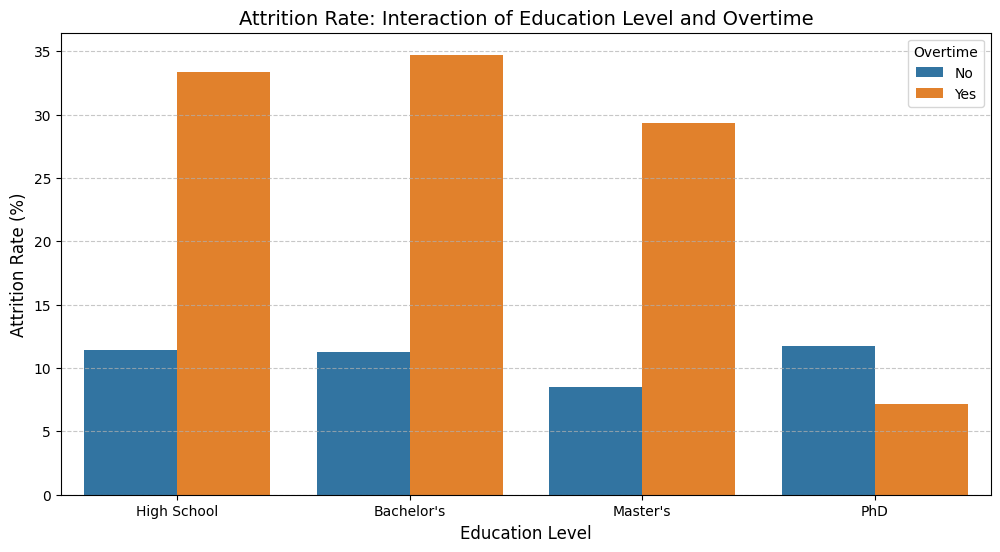

In [9]:
edu_display_map = {
    1: "High School",
    3: "Bachelor's",
    4: "Master's",
    5: "PhD"
}

plot_data_1 = causal_interaction[causal_interaction['Edu_Level'] != 2].copy()
plot_data_1['Edu_Label'] = plot_data_1['Edu_Level'].map(edu_display_map)

plt.figure(figsize=(12, 6))
sns.barplot(x='Edu_Label', y='Attrition_Percent', hue='OverTime', 
            data=plot_data_1, 
            order=["High School", "Bachelor's", "Master's", "PhD"])

plt.title('Attrition Rate: Interaction of Education Level and Overtime', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.legend(title='Overtime')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

I was able to find out there is a strong relationship between overtime and attration rate for all educatio level except PhD. For workers who graduated from high school as the highest education, they have about 11% attrition rate without overtime and about 34% of attrition rate with experiencing overtime. Workers who have experienced overtime have about 3 times higher attrition rate. For Bachelor's, workers without overtime have around 12% attrition rate and people who work overtime have 35% of attrition rate which is the highest in this figure. Master's also has the same result where there is abobut 14% of attrition rate without overtime and around 29% without overtime which is more than double. Surprisingly, workers with PhD degree is completely opposite where poeple without overtime have higher attrition rate. This may be because their work is research-oriented and rewarding. They are typically high paying and have specialized role that are difficult to leave and overtime might be similar to discretionary work. Therefore, overtime might not equal to simply a stress for them. 

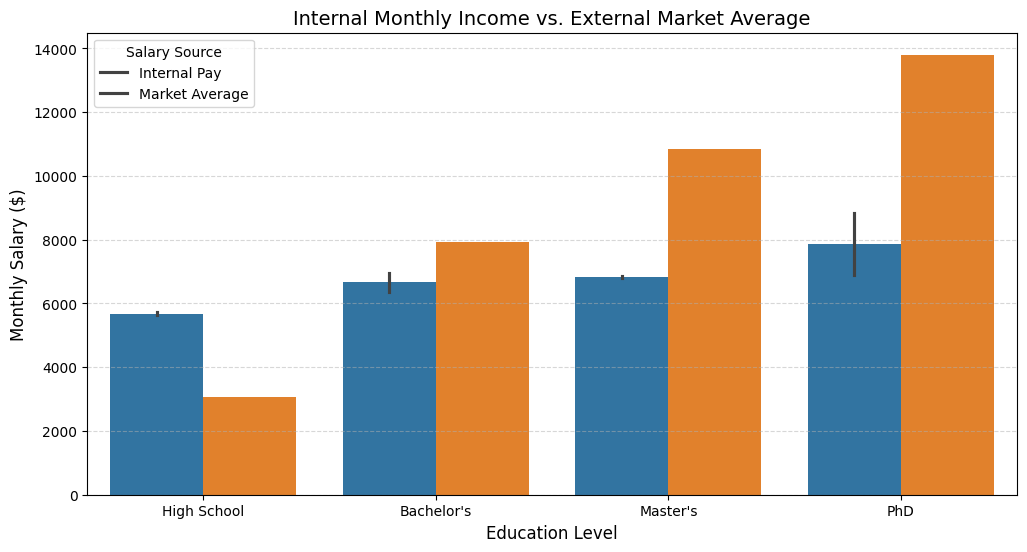

In [10]:
pay_comp = causal_interaction[causal_interaction['Edu_Level'] != 2].copy()
pay_comp = pay_comp[['Edu_Level', 'Internal_Pay', 'Market_Pay_Avg']].melt(id_vars='Edu_Level')

pay_comp['Edu_Label'] = pay_comp['Edu_Level'].map(edu_display_map)

plt.figure(figsize=(12, 6))
sns.barplot(x='Edu_Label', y='value', hue='variable', 
            data=pay_comp,
            order=["High School", "Bachelor's", "Master's", "PhD"])

plt.title('Internal Monthly Income vs. External Market Average', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Monthly Salary ($)', fontsize=12)
plt.legend(title='Salary Source', labels=['Internal Pay', 'Market Average'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

This figure compares internal income with market average. I found out that those with higher degree have a bigger payment gap with the average market pay. In other words, people with higher degree tend to have underpaid than those with lower degree. This is a huge factor for the attrition rate. People with high school degree as their highest education get about $5800, whereas its market average is about $3000 so there is some competitiveness. On the other hand, those with Bachelor's, Master's and PhD were payed much lower than the market average. This connects with the first plot where there is a higher risk of attrition especially for those with higher than Bachelor's degree. 

3. Role-Specific Flight Risk (For Master's/PhD)
Purpose: This uses the parameterized query results to show which specific jobs have the worst pay gap for a specific degree (e.g., PhD)

/var/folders/8b/l3hn2xz95s339fcjyn4t7t8r0000gn/T/ipykernel_26206/3562501331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pay_Difference', y='JobRole', data=edu_role_gap, palette='coolwarm')


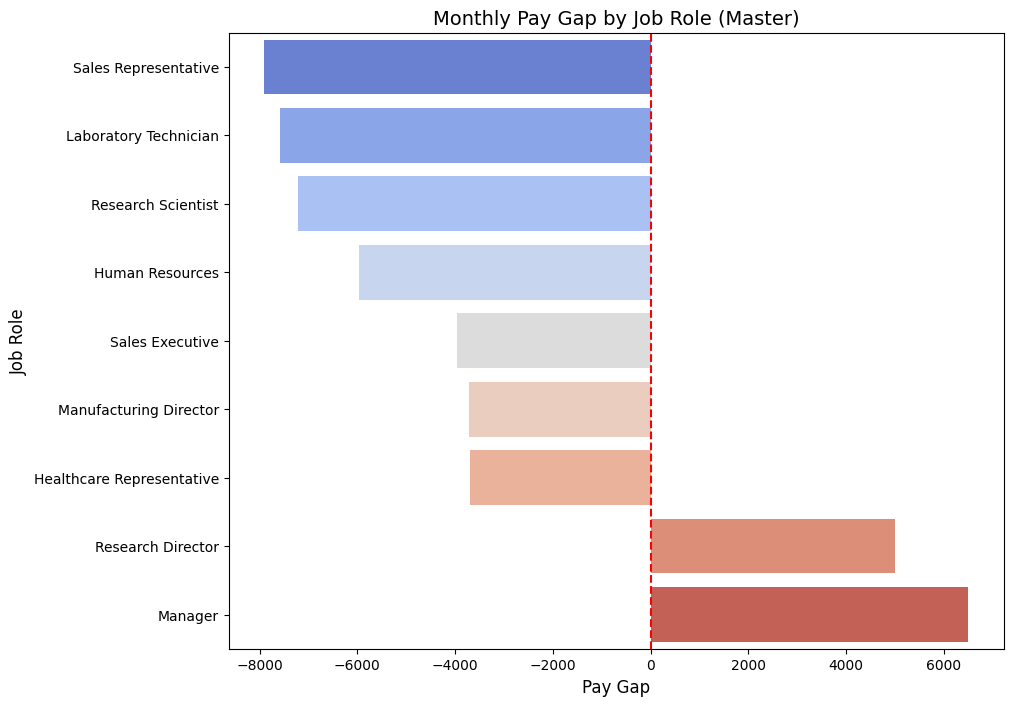

In [11]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Pay_Difference', y='JobRole', data=edu_role_gap, palette='coolwarm')

plt.title('Monthly Pay Gap by Job Role (Master)', fontsize=14)
plt.xlabel('Pay Gap', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.axvline(0, color='red', linestyle='--')
plt.show()

I chose Master's degree to take a look at this issue more specifically. I found out the payment gap is depend on what types of job they have. For example, poeple with Master's degree and work as a sales representaitve have the biggest payment gap with their internal payment and the market average. They have about $-8000 which is much lower then the average. On the other hand, people who work as a manager receive much higher than the market average. 

4. Departmental Burnout Intensity (Heatmap)
Purpose: To see if overtime-driven attrition is a company-wide problem or concentrated in specific areas like Sales or R&D

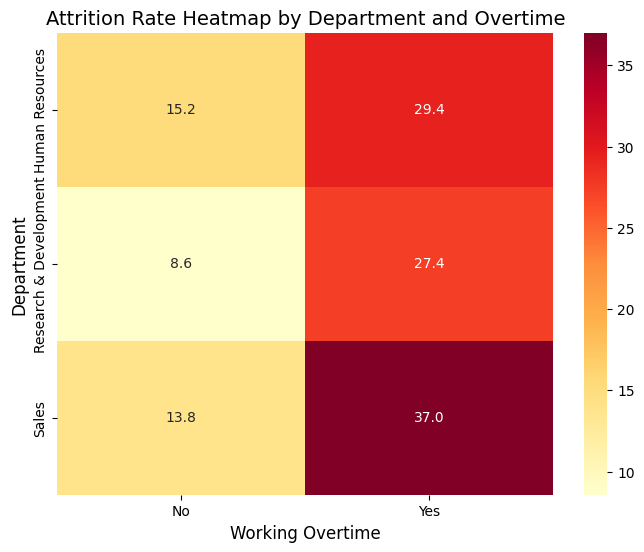

In [ ]:
heatmap_data = dept_burnout.pivot(index='Department', columns='OverTime', values='Attrition_Rate')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt=".1f")

plt.title('Attrition Rate Heatmap by Department and Overtime', fontsize=14)
plt.xlabel('Working Overtime', fontsize=12)
plt.ylabel('Department', fontsize=12)
plt.show()

This figure shows that the biggest issue of attrition is the overtime of sales division. When we take a look at three departments without any overtime, HR has about 15.2%, R&D has 8.6% and Sales has 13.8% which is pretty stable. However, if there is some overtime working, the result will be very different. For HR, the attrition rate is doubled, R&D has tripled, and sales' attrition rate is also tripled. So in this company, sales division is the biggest issue that increases attrition rate. 

# Conclusion

In conclusion, an attrition rate tends to increase when there is overtime and huge payment gap. I was able to find out that the biggest driver of attrition is whether people work onvertime or not. The attrition rate is about doubled or even tripled if employees work onvertime and in the sales department, the attrition rate increases up to 37.5% which is very high. This might be because sales is a job that is easier to change careers and others such as R&D. However, overtime is not the only reason why the attrition is increasing in this company. I also found out that the those with a higher education level are payed lower than the market average. The figure shows that those who have a high degree as their highest education are payed higher than the market average for those with same condition (High school as the highest education) but for Bachelor's, Master's and PhD, they are underpaid than their market average which shows that even they studied and worked hard, their effor goes unrewarded. Therefore, people who tend to leave a company is those with overtime, underpaid compared to the average market and a job that is easy to switch to. That is why our data shows that the attrition rate of sales department is 37.5%. 